# IT25103994 — Amarathunge W. R. P. N.
## Individual Preprocessing Task: Encoding Categorical Variables
**Dataset:** Chronic Kidney Disease (UCI ML Repository, id 336)
**Group:** 2026-Y2-S1-KU-56

This notebook demonstrates my individually assigned preprocessing technique — **encoding categorical
variables** — applied to the CKD dataset (building on the missing-value-handled output from Hansaka's
notebook, `IT25103993_missing_handled.csv`, as the group pipeline does).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
df = pd.read_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103994_encoded.csv')
print(df.shape)
df.dtypes

(399, 25)


,0
age,float64
bp,float64
sg,float64
al,float64
su,float64
rbc,object
pc,object
pcc,object
ba,object
bgr,float64


### Why this technique is needed for this dataset
14 of the 25 columns in the CKD dataset are categorical/nominal (e.g. `rbc`, `htn`, `appet`, `class`), stored
as text such as `normal`/`abnormal` or `yes`/`no`. Machine-learning algorithms such as SVM, Logistic
Regression, or Neural Networks require numeric input, so these text categories must be converted to numbers
before modelling.

In [ ]:
binary_cols = ['rbc','pc','pcc','ba','htn','dm','cad','appet','pe','ane','class']
for c in binary_cols:
    print(c, '->', df[c].unique())

rbc -> [nan 'normal' 'abnormal']
pc -> ['normal' 'abnormal' nan]
pcc -> ['notpresent' 'present' nan]
ba -> ['notpresent' 'present' nan]
htn -> ['yes' 'no' nan]
dm -> ['yes' 'no' nan]
cad -> ['no' 'yes' nan]
appet -> ['good' 'poor' nan]
pe -> ['no' 'yes' nan]
ane -> ['no' 'yes' nan]
class -> ['ckd' 'notckd']


/tmp/ipykernel_2411/1391141537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette=['indianred','seagreen'])


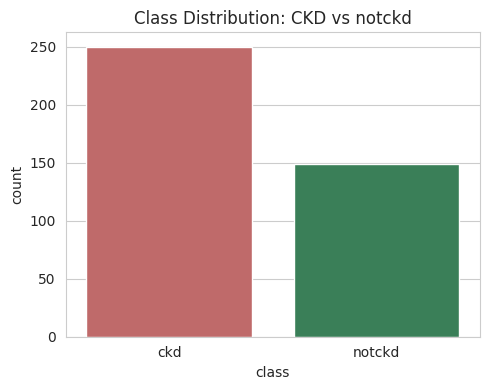

,count
class,
ckd,250
notckd,149


In [ ]:
# EDA Visualization 1: class balance before encoding
plt.figure(figsize=(5,4))
sns.countplot(x='class', data=df, palette=['indianred','seagreen'])
plt.title('Class Distribution: CKD vs notckd')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103994_class_balance.png', dpi=120)
plt.show()
df['class'].value_counts()

**Interpretation:** The dataset is moderately imbalanced (250 CKD vs 149 notckd, roughly 63%/37%). This
is worth noting for later modelling — metrics like accuracy alone can be misleading on an imbalanced dataset,
so F1-score / confusion matrices (required in Step 4 of the assignment) will matter more.

In [ ]:
df_encoded = df.copy()

# All 11 binary categorical columns are label-encoded (2 categories each -> 0/1 is a safe, lossless mapping)
label_encoders = {}
for col in binary_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_)))

for col in binary_cols:
    print(col, label_encoders[col])

rbc {'abnormal': np.int64(0), 'nan': np.int64(1), 'normal': np.int64(2)}
pc {'abnormal': np.int64(0), 'nan': np.int64(1), 'normal': np.int64(2)}
pcc {'nan': np.int64(0), 'notpresent': np.int64(1), 'present': np.int64(2)}
ba {'nan': np.int64(0), 'notpresent': np.int64(1), 'present': np.int64(2)}
htn {'nan': np.int64(0), 'no': np.int64(1), 'yes': np.int64(2)}
dm {'nan': np.int64(0), 'no': np.int64(1), 'yes': np.int64(2)}
cad {'nan': np.int64(0), 'no': np.int64(1), 'yes': np.int64(2)}
appet {'good': np.int64(0), 'nan': np.int64(1), 'poor': np.int64(2)}
pe {'nan': np.int64(0), 'no': np.int64(1), 'yes': np.int64(2)}
ane {'nan': np.int64(0), 'no': np.int64(1), 'yes': np.int64(2)}
class {'ckd': np.int64(0), 'notckd': np.int64(1)}


In [ ]:
# sg, al, su are ordinal-looking nominal attributes already stored as numeric-like strings -> convert to numeric directly
ordinal_cols = ['sg','al','su']
for col in ordinal_cols:
    df_encoded[col] = pd.to_numeric(df_encoded[col])

df_encoded[binary_cols + ordinal_cols].head()

,rbc,pc,pcc,ba,htn,dm,cad,appet,pe,ane,class,sg,al,su
0,1,2,1,1,2,2,1,0,1,1,0,1.020,1.0,0.0
1,1,2,1,1,1,1,1,0,1,1,0,1.020,4.0,0.0
2,2,2,1,1,1,2,1,2,1,2,0,1.010,2.0,3.0
3,2,0,2,1,2,1,1,2,2,2,0,1.005,4.0,0.0
4,2,2,1,1,1,1,1,0,1,1,0,1.010,2.0,0.0


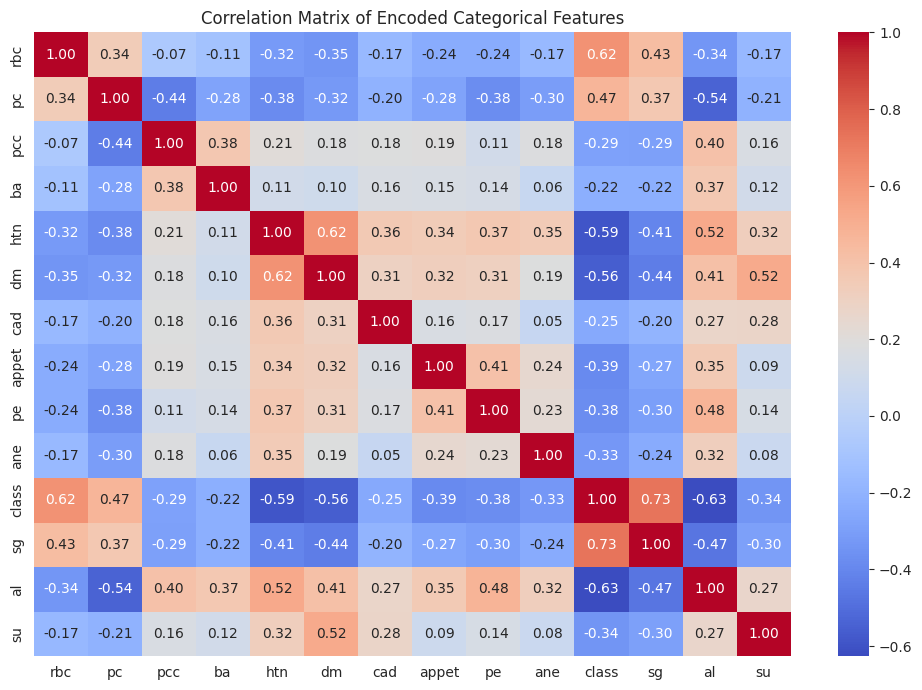

In [ ]:
# EDA Visualization 2: correlation of encoded categorical features with the target class
plt.figure(figsize=(10,7))
corr = df_encoded[binary_cols + ordinal_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix of Encoded Categorical Features')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/eda_visualizations/IT25103994_categorical_correlation_heatmap.png', dpi=120)
plt.show()

**Interpretation:** `class` correlates strongly with `htn` (hypertension), `dm` (diabetes mellitus),
`appet` (appetite) and `al` (albumin) — consistent with medical knowledge that hypertension and diabetes are
major risk factors for chronic kidney disease, and albuminuria (protein in urine) is itself a diagnostic
marker of kidney damage. This gives an early signal about which features will likely be important
predictors in Step 3 (model design).

In [ ]:
df_encoded.to_csv('/content/drive/MyDrive/Group_ID_2026-Y2-S1-KU-56/Group_ID/results/outputs/IT25103994_encoded.csv', index=False)
print("Saved fully-numeric dataset for downstream use by the group pipeline.")

NameError: name 'df_encoded' is not defined

### Summary
- **Technique:** Categorical encoding — Label Encoding for 11 binary nominal features (`rbc`, `pc`, `pcc`,
  `ba`, `htn`, `dm`, `cad`, `appet`, `pe`, `ane`, `class`), and direct numeric conversion for 3 ordinal-coded
  features (`sg`, `al`, `su`).
- **Justification:** Binary categories map losslessly to 0/1 with Label Encoding (no artificial ordinal
  relationship is implied since there are only 2 classes per column, so one-hot encoding was unnecessary
  here and would only add redundant columns).
- **Output:** `results/outputs/IT25103994_encoded.csv` — fully numeric dataset, ready for scaling.